In [75]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.types import Tensor

import darksun as ds
from darksun.show import DSPlot

ds.show.set_figures_darkbkg()

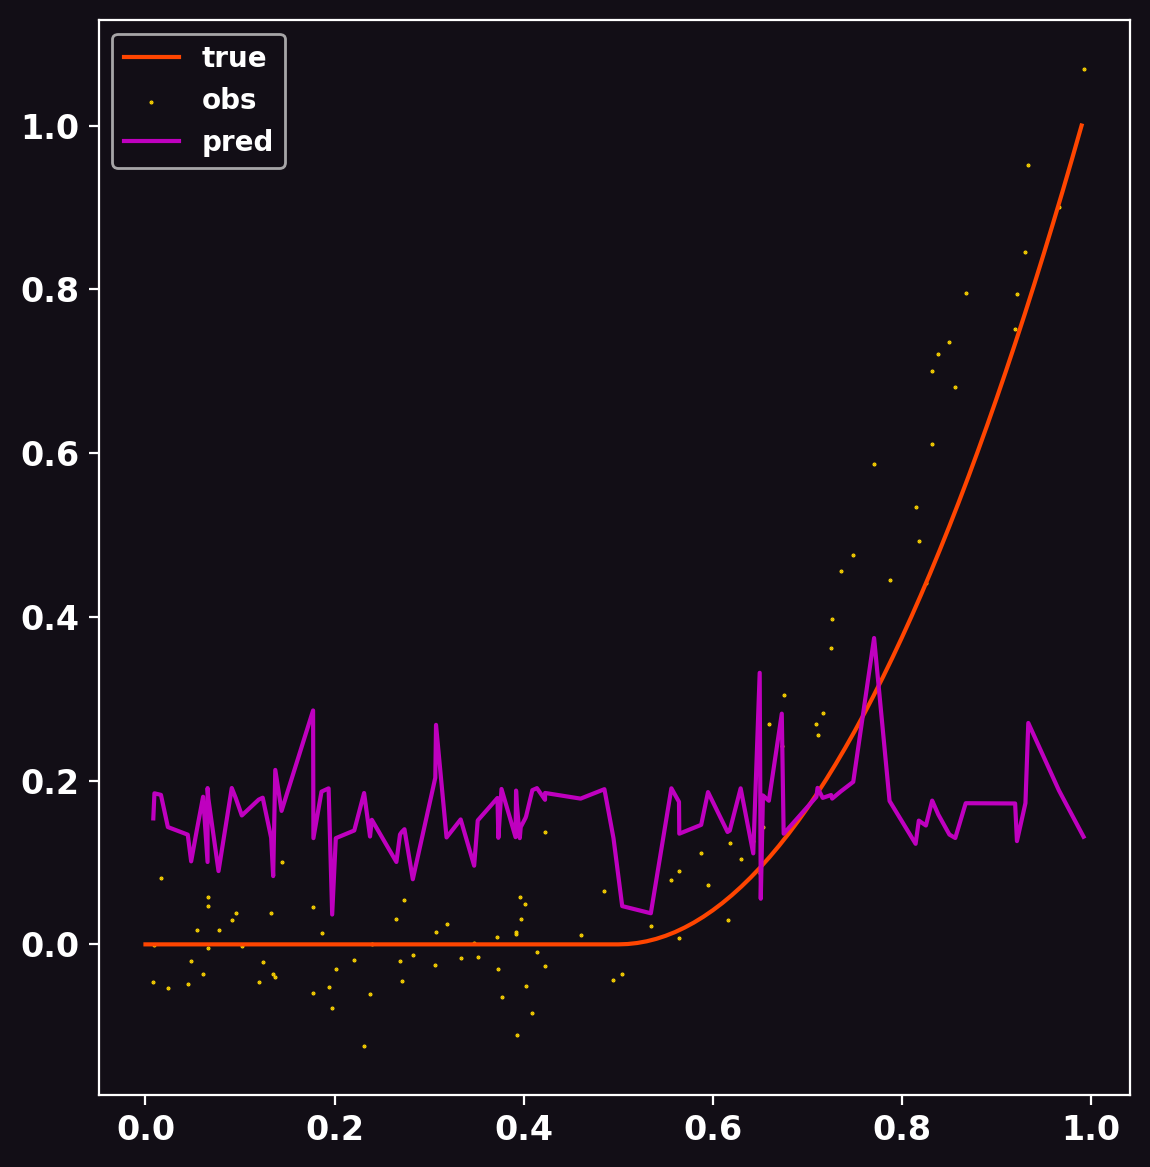

In [87]:
def model(n: int) -> Tensor:
    """Generate data through custom model."""
    lin = torch.zeros(int(np.floor(n // 2)))
    sq = torch.square(torch.linspace(0, 1, int(np.ceil(n // 2))))
    return torch.concat((lin, sq)).sort()[0]

def polyfit(x: Tensor, y: Tensor, degree: int) -> Tensor:
    """Performs a polynomial fit of the given data."""
    X = x.unsqueeze(1) ** torch.arange(0, degree + 1)
    coeffs = torch.linalg.lstsq(X, y).solution
    return coeffs

def eval_fit(x: Tensor, coeffs: Tensor) -> Tensor:
    """Evaluates the data as polynomial with given coeffs."""
    X = x.unsqueeze(1) ** torch.arange(0, len(coeffs))
    Y = X @ coeffs
    return Y


# hyperparams
n: int = 100
sigma: float = 5e-2
degree: int = 3
# data
x = torch.rand(n)
true = model(n)
obs = true + torch.normal(torch.zeros_like(x), sigma * torch.ones_like(x))
# perform lstsq fit
alpha = polyfit(x, obs, degree)
pred = eval_fit(x, alpha)
# show results
x_ = x.sort()[0]
dsp = DSPlot(1, 1)
fig, ax = dsp.config_subplots()
ax.plot(torch.arange(0, len(true)) / len(true), true, c='OrangeRed', label='true')
ax.scatter(x_, obs, c='Gold', label='obs', s=0.2)
ax.plot(x_, pred, c='m', label='pred')
ax.legend(loc='best')
plt.show()

In [55]:
true, obs, pred, torch.sqrt(torch.mean(torch.square(obs - pred)))

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.7886, 0.2602, 0.6484, 0.8005, 0.9257, 0.5963,
         0.5620, 0.9224]),
 tensor([ 2.9508e-03,  1.8992e-03, -5.4118e-03,  3.4561e-03,  5.2243e-03,
          2.1408e-03,  2.5737e-05, -5.6154e-03, -1.4541e-03,  1.1820e-05,
          9.6454e-03, -4.0251e-03,  7.8796e-01,  2.5069e-01,  6.4514e-01,
          7.9148e-01,  9.2621e-01,  6.0395e-01,  5.6283e-01,  9.2732e-01]),
 tensor([0.2585, 0.1339, 0.1891, 0.1621, 0.1428, 0.4632, 0.1434, 0.1224, 0.3313,
         0.2129, 0.2185, 0.2470, 0.1646, 0.4755, 0.6146, 0.2888, 0.2277, 0.2629,
         0.2347, 0.6107]),
 tensor(0.3303))